# Household Peak Prediction, Weather Checks and Fairness Analysis

This Kaggle notebook uses two inputs:

1. `sensordata.zip`, containing the raw household sensor data.
2. `supervised_95_features.csv.gz`, containing the prepared modelling data and weather variables.

The prepared CSV already includes temperature, humidity, precipitation, wind speed, load lags, targets, demographic groups and chronological train/validation/test splits. The raw sensor ZIP is therefore inspected for reference, while the prepared CSV is used for modelling.

> Attach both files to the Kaggle notebook using **Add Input**, then run the cells from top to bottom.


## Cell 1 — Install missing packages

Kaggle normally includes these packages. This cell only installs a package when it is missing.


In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "seaborn": "seaborn",
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

print("Package check complete.")

Package check complete.


## Cell 2 — Imports and configuration


In [2]:
import gc
import os
import re
import shutil
import warnings
import zipfile
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42

# Start with True to verify that everything runs.
# Change to False for the complete experiment.
DEMO_MODE = True

DEMO_ROWS = {
    "train": 100_000,
    "validation": 10_000,
    "test": 10_000,
}

BOOTSTRAP_REPEATS = 500 if DEMO_MODE else 5_000

KAGGLE_INPUT = Path("/kaggle/input")
WORKING_DIR = Path("/kaggle/working")
EXTRACT_DIR = WORKING_DIR / "household_extracted"
OUTPUT_DIR = WORKING_DIR / "household_peak_outputs"

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Kaggle input exists:", KAGGLE_INPUT.exists())
print("Demo mode:", DEMO_MODE)
print("Output directory:", OUTPUT_DIR)

Kaggle input exists: True
Demo mode: True
Output directory: /kaggle/working/household_peak_outputs


def find_prepared_dataset(input_root: Path = KAGGLE_INPUT) -> Optional[Path]:
    """Find the model-ready table without depending on a Kaggle folder name."""
    if not input_root.exists():
        return None

    exact_matches = sorted(input_root.rglob("supervised_95_features.csv.gz"))
    if exact_matches:
        return exact_matches[0]

    supported_suffixes = (".csv", ".csv.gz", ".parquet", ".feather")
    flexible_matches = sorted(
        path for path in input_root.rglob("*")
        if path.is_file()
        and "supervised" in path.name.lower()
        and path.name.lower().endswith(supported_suffixes)
    )
    return flexible_matches[0] if flexible_matches else None


PREPARED_DATA_FILE = find_prepared_dataset()
if PREPARED_DATA_FILE is None:
    print(
        "Prepared dataset not found. Attach the Kaggle input containing "
        "supervised_95_features.csv.gz, then rerun from this cell."
    )
else:
    print("Prepared modelling and weather file:")
    print(PREPARED_DATA_FILE)
    print(f"Compressed size: {PREPARED_DATA_FILE.stat().st_size / (1024**2):.2f} MB")


In [3]:
def find_prepared_dataset(input_root=KAGGLE_INPUT):
    exact_matches = sorted(
        input_root.glob('**/supervised_95_features.csv.gz')
    )

    if exact_matches:
        return exact_matches[0]

    flexible_matches = sorted(
        path for path in input_root.glob('**/*')
        if path.is_file()
        and 'supervised' in path.name.lower()
        and path.name.lower().endswith(('.csv', '.csv.gz', '.parquet'))
    )

    if flexible_matches:
        return flexible_matches[0]

    raise FileNotFoundError(
        'Could not find supervised_95_features.csv.gz under /kaggle/input. '
        'Use Add Input to attach the dataset containing this file.'
    )


PREPARED_DATA_FILE = find_prepared_dataset()
print('Prepared modelling and weather file:')
print(PREPARED_DATA_FILE)
print(f'Compressed size: {PREPARED_DATA_FILE.stat().st_size / (1024**2):.2f} MB')


Prepared modelling and weather file:
/kaggle/input/datasets/adeboyejoisaac/supervised-data/supervised_95_features.csv
Compressed size: 181.73 MB


## Cell 4 — Find the `household data` folder and `sensordata.zip`

Kaggle usually converts spaces in dataset names to hyphens. Therefore, a dataset called **household data** may appear as:

`/kaggle/input/household-data`


In [4]:
def normalise_name(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", value.lower())


def find_household_roots(input_root: Path = KAGGLE_INPUT) -> List[Path]:
    if not input_root.exists():
        raise FileNotFoundError(
            "/kaggle/input was not found. Run this notebook inside Kaggle "
            "and attach the dataset using Add Input."
        )

    roots = [p for p in input_root.iterdir() if p.is_dir()]
    household_roots = [
        p for p in roots
        if "household" in normalise_name(p.name)
    ]

    return household_roots or roots


HOUSEHOLD_ROOTS = find_household_roots()

print("Candidate Kaggle dataset folders:")
for folder in HOUSEHOLD_ROOTS:
    print(" -", folder)


def find_files(
    roots: Iterable[Path],
    suffixes: Optional[Tuple[str, ...]] = None,
    name_contains: Optional[Tuple[str, ...]] = None,
) -> List[Path]:
    results = []

    for root in roots:
        for path in root.rglob("*"):
            if not path.is_file():
                continue

            name_lower = path.name.lower()

            if suffixes and not name_lower.endswith(suffixes):
                continue

            if name_contains and not all(term.lower() in name_lower for term in name_contains):
                continue

            results.append(path)

    return sorted(results)


ZIP_FILES = find_files(HOUSEHOLD_ROOTS, suffixes=(".zip",))
SENSOR_ZIPS = [
    p for p in ZIP_FILES
    if "sensor" in normalise_name(p.name)
]

print("\nZIP files found:")
for path in ZIP_FILES:
    size_gb = path.stat().st_size / (1024 ** 3)
    print(f" - {path} ({size_gb:.3f} GB)")

if SENSOR_ZIPS:
    SENSOR_ZIP = SENSOR_ZIPS[0]
    print("\nSelected sensor ZIP:", SENSOR_ZIP)
else:
    SENSOR_ZIP = None
    print("\nNo ZIP containing 'sensor' was found.")

Candidate Kaggle dataset folders:
 - /kaggle/input/datasets

ZIP files found:

No ZIP containing 'sensor' was found.


## Cell 5 — Inspect the ZIP before extracting it


In [5]:
def inspect_zip(zip_path: Path, preview_rows: int = 40) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as archive:
        records = []
        for item in archive.infolist():
            if item.is_dir():
                continue
            records.append({
                "file": item.filename,
                "compressed_mb": item.compress_size / (1024 ** 2),
                "uncompressed_mb": item.file_size / (1024 ** 2),
            })

    inventory = pd.DataFrame(records).sort_values(
        "uncompressed_mb", ascending=False
    ).reset_index(drop=True)

    print(f"Files inside ZIP: {len(inventory):,}")
    print(
        "Total uncompressed size: "
        f"{inventory['uncompressed_mb'].sum() / 1024:.2f} GB"
    )

    return inventory


if SENSOR_ZIP is not None:
    zip_inventory = inspect_zip(SENSOR_ZIP)
    display(zip_inventory.head(40))
else:
    zip_inventory = pd.DataFrame()
    print("Skip: no sensor ZIP was found.")

Skip: no sensor ZIP was found.


## Cell 6 — Extract `sensordata.zip`

Extraction is skipped when the destination already contains files. Set `FORCE_EXTRACT = True` to extract again.


In [6]:
FORCE_EXTRACT = False

def extract_zip(zip_path: Path, destination: Path, force: bool = False) -> None:
    existing_files = [p for p in destination.rglob("*") if p.is_file()]

    if existing_files and not force:
        print(
            f"Extraction skipped: {len(existing_files):,} files already exist in "
            f"{destination}"
        )
        return

    if force and destination.exists():
        shutil.rmtree(destination)
        destination.mkdir(parents=True, exist_ok=True)

    print("Extracting:", zip_path)
    print("Destination:", destination)

    destination_resolved = destination.resolve()
    with zipfile.ZipFile(zip_path, "r") as archive:
        for member in archive.infolist():
            member_path = (destination / member.filename).resolve()
            if destination_resolved not in member_path.parents and member_path != destination_resolved:
                raise ValueError(f"Unsafe path inside ZIP: {member.filename}")
        archive.extractall(destination)

    extracted_count = sum(1 for p in destination.rglob("*") if p.is_file())
    print(f"Extraction complete. Files extracted: {extracted_count:,}")


if SENSOR_ZIP is not None:
    extract_zip(SENSOR_ZIP, EXTRACT_DIR, force=FORCE_EXTRACT)
else:
    print("Skip: no sensor ZIP was found.")

Skip: no sensor ZIP was found.


## Cell 7 — Inventory all sensor and weather files


In [7]:
TABULAR_SUFFIXES = (
    ".csv", ".csv.gz", ".txt", ".tsv", ".parquet",
    ".feather", ".json", ".xlsx"
)

SEARCH_ROOTS = list(HOUSEHOLD_ROOTS)
if EXTRACT_DIR.exists():
    SEARCH_ROOTS.append(EXTRACT_DIR)

all_tabular_files = find_files(
    SEARCH_ROOTS,
    suffixes=TABULAR_SUFFIXES,
)

weather_files = [
    p for p in all_tabular_files
    if any(term in normalise_name(str(p)) for term in (
        "weather", "temperature", "humidity",
        "precipitation", "windspeed", "metoffice"
    ))
]

sensor_files = [
    p for p in all_tabular_files
    if any(term in normalise_name(str(p)) for term in (
        "sensor", "electric", "electricity", "power",
        "energy", "mains", "appliance"
    ))
]

inventory = pd.DataFrame({
    "path": [str(p) for p in all_tabular_files],
    "filename": [p.name for p in all_tabular_files],
    "suffix": ["".join(p.suffixes).lower() for p in all_tabular_files],
    "size_mb": [p.stat().st_size / (1024 ** 2) for p in all_tabular_files],
})

if not inventory.empty:
    inventory = inventory.sort_values("size_mb", ascending=False).reset_index(drop=True)

print(f"All tabular files: {len(all_tabular_files):,}")
print(f"Likely sensor files: {len(sensor_files):,}")
print(f"Likely weather files: {len(weather_files):,}")

display(inventory.head(50))

print("\nLikely weather files:")
for path in weather_files[:50]:
    print(" -", path)

All tabular files: 1,594
Likely sensor files: 1,593
Likely weather files: 1


,path,filename,suffix,size_mb
0,/kaggle/input/datasets/adeboyejoisaac/househol...,home62_hall705_sensor1662c1666_electric-mains_...,.csv,1216.212834
1,/kaggle/input/datasets/adeboyejoisaac/househol...,home65_hall731_sensor1910c1912_electric-mains_...,.csv,1093.010066
2,/kaggle/input/datasets/adeboyejoisaac/househol...,home68_utility757_sensor2122c2126_electric-mai...,.csv,1088.847585
3,/kaggle/input/datasets/adeboyejoisaac/househol...,home64_hall713_sensor1810c1814_electric-mains_...,.csv,1066.316794
4,/kaggle/input/datasets/adeboyejoisaac/househol...,home70_hall774_sensor2299c2303_electric-mains_...,.csv,1048.625885
5,/kaggle/input/datasets/adeboyejoisaac/househol...,home67_hall767_sensor2242c2246_electric-mains_...,.csv,1039.219551
6,/kaggle/input/datasets/adeboyejoisaac/househol...,home66_utility745_sensor2045c2049_electric-mai...,.csv,1029.744178
7,/kaggle/input/datasets/adeboyejoisaac/househol...,home72_hall796_sensor2476c2480_electric-mains_...,.csv,976.827947
8,/kaggle/input/datasets/adeboyejoisaac/househol...,home82_hall891_sensor3242c3246_electric-mains_...,.csv,954.935210
9,/kaggle/input/datasets/adeboyejoisaac/househol...,home71_hall824_sensor2713c2715_electric-mains_...,.csv,947.459805



Likely weather files:
 - /kaggle/input/datasets/adeboyejoisaac/household-dataset/sensordata/weatherreading.csv


## Cell 8 — Safely inspect columns without loading entire large files

This cell reads only a small preview.


In [8]:
def read_preview(path: Path, nrows: int = 5) -> pd.DataFrame:
    name = path.name.lower()

    if name.endswith(".parquet"):
        return pd.read_parquet(path).head(nrows)

    if name.endswith(".feather"):
        return pd.read_feather(path).head(nrows)

    if name.endswith(".xlsx"):
        return pd.read_excel(path, nrows=nrows)

    if name.endswith(".json"):
        return pd.read_json(path).head(nrows)

    # Try common separators for text files.
    attempts = [
        {"sep": ","},
        {"sep": "\t"},
        {"sep": ";"},
        {"sep": None, "engine": "python"},
    ]

    last_error = None

    for options in attempts:
        try:
            return pd.read_csv(
                path,
                nrows=nrows,
                low_memory=False,
                **options,
            )
        except Exception as error:
            last_error = error

    raise RuntimeError(f"Could not preview {path}: {last_error}")


def inspect_files(paths: List[Path], limit: int = 20) -> pd.DataFrame:
    rows = []

    for path in paths[:limit]:
        try:
            preview = read_preview(path, nrows=5)
            rows.append({
                "path": str(path),
                "size_mb": path.stat().st_size / (1024 ** 2),
                "rows_previewed": len(preview),
                "column_count": len(preview.columns),
                "columns": list(preview.columns),
                "status": "OK",
            })
        except Exception as error:
            rows.append({
                "path": str(path),
                "size_mb": path.stat().st_size / (1024 ** 2),
                "rows_previewed": 0,
                "column_count": 0,
                "columns": [],
                "status": f"ERROR: {error}",
            })

    return pd.DataFrame(rows)


print("Sensor-file inspection:")
sensor_inspection = inspect_files(sensor_files, limit=25)
display(sensor_inspection)

print("\nWeather-file inspection:")
weather_inspection = inspect_files(weather_files, limit=25)
display(weather_inspection)

Sensor-file inspection:


,path,size_mb,rows_previewed,column_count,columns,status
0,/kaggle/input/datasets/adeboyejoisaac/househol...,3.043404,5,2,"[2017-03-07 14:29:36, 316]",OK
1,/kaggle/input/datasets/adeboyejoisaac/househol...,52.449229,5,2,"[2017-03-07 14:13:20, 170]",OK
2,/kaggle/input/datasets/adeboyejoisaac/househol...,52.447292,5,2,"[2017-03-07 14:13:20, 168]",OK
3,/kaggle/input/datasets/adeboyejoisaac/househol...,35.142001,5,2,"[2017-03-07 14:14:59, 125]",OK
4,/kaggle/input/datasets/adeboyejoisaac/househol...,35.184705,5,2,"[2017-03-07 14:14:59, 163]",OK
5,/kaggle/input/datasets/adeboyejoisaac/househol...,810.933119,5,2,"[2017-03-07 14:22:48, 0]",OK
6,/kaggle/input/datasets/adeboyejoisaac/househol...,809.723403,5,2,"[2017-03-09 08:35:07, 0]",OK
7,/kaggle/input/datasets/adeboyejoisaac/househol...,69.649950,5,2,"[2017-03-09 08:47:09, 225]",OK
8,/kaggle/input/datasets/adeboyejoisaac/househol...,69.638551,5,2,"[2017-03-09 08:47:09, 228]",OK
9,/kaggle/input/datasets/adeboyejoisaac/househol...,67.902688,5,2,"[2017-03-09 08:52:26, 110]",OK



Weather-file inspection:


,path,size_mb,rows_previewed,column_count,columns,status
0,/kaggle/input/datasets/adeboyejoisaac/househol...,30.439819,5,3,"[feedid, time, value]",OK


## Weather data checks inside the prepared CSV

This verifies the weather coverage, missing values and distributions before model training.


Weather rows: 509,053
Weather period: 2016-11-16 05:00:00 to 2018-06-29 23:00:00

Locations:


,rows
location,
Edinburgh,397124
Midlothian,81202
WestLothian,21802
EastLothian,8925


,missing_rows,missing_percent,minimum,mean,maximum
origin_temperature_2m_c,0,0.0,-5.5,9.882,27.6
origin_relative_humidity_2m_pct,0,0.0,31.0,81.524,100.0
origin_precipitation_mm,0,0.0,0.0,0.078,4.9
origin_wind_speed_10m_kmh,0,0.0,0.0,15.564,56.9
temperature_lag_24h_c,0,0.0,-4.8,9.866,27.6
humidity_lag_24h_pct,0,0.0,31.0,81.563,100.0
precipitation_lag_24h_mm,0,0.0,0.0,0.081,6.2
wind_speed_lag_24h_kmh,0,0.0,0.0,15.590,56.9


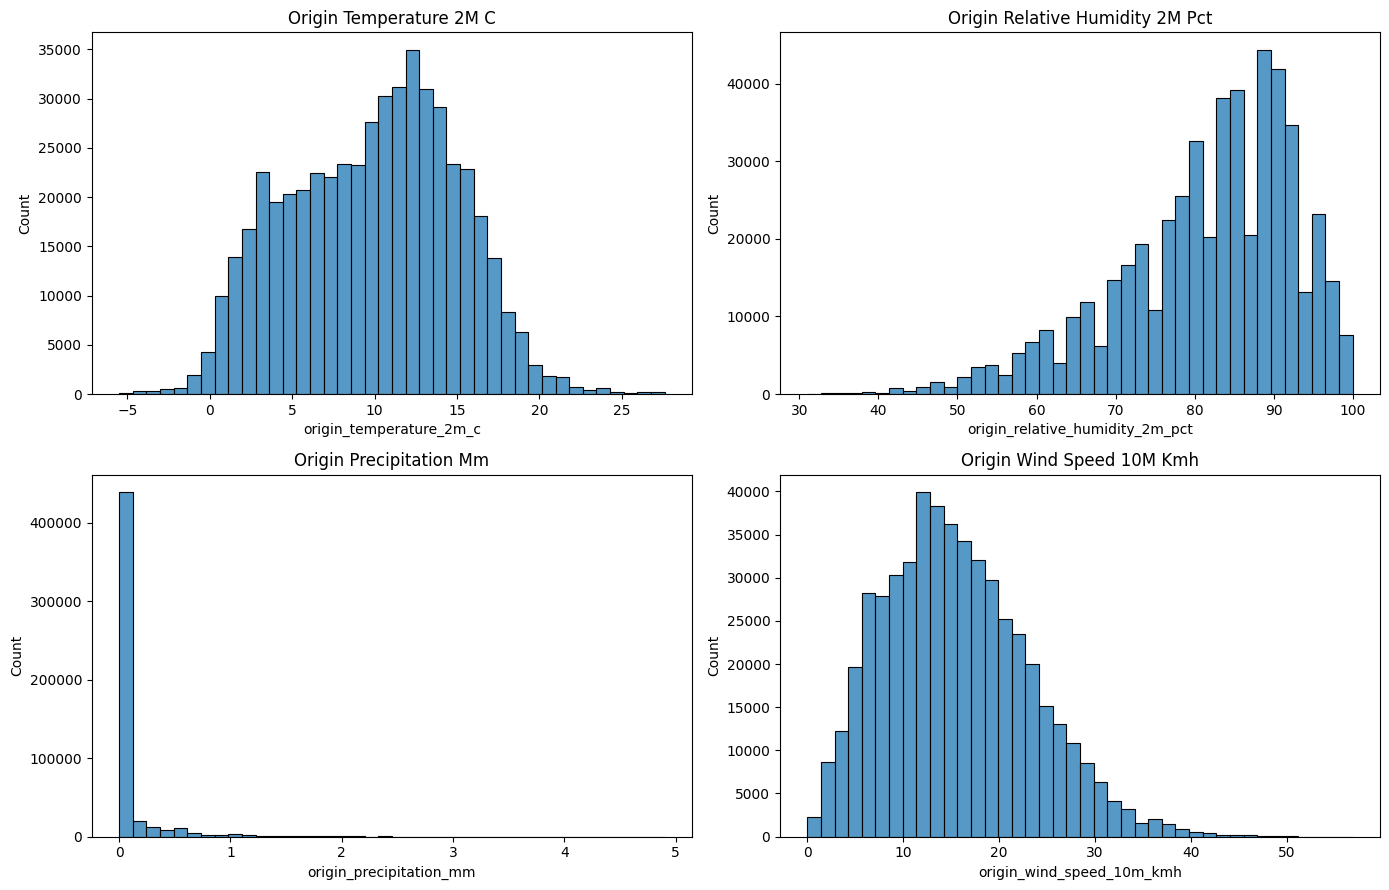

In [9]:
WEATHER_CHECK_COLUMNS = [
    'origin_timestamp_utc',
    'location',
    'origin_temperature_2m_c',
    'origin_relative_humidity_2m_pct',
    'origin_precipitation_mm',
    'origin_wind_speed_10m_kmh',
    'temperature_lag_24h_c',
    'humidity_lag_24h_pct',
    'precipitation_lag_24h_mm',
    'wind_speed_lag_24h_kmh',
]

if PREPARED_DATA_FILE is None:
    print("Skip: prepared weather/model table is unavailable.")
else:
    header = pd.read_csv(PREPARED_DATA_FILE, nrows=0)
    missing_weather_columns = sorted(set(WEATHER_CHECK_COLUMNS) - set(header.columns))
    if missing_weather_columns:
        print("Weather check skipped; missing columns:", missing_weather_columns)
    else:
        weather_data = pd.read_csv(
            PREPARED_DATA_FILE,
            usecols=WEATHER_CHECK_COLUMNS,
            parse_dates=['origin_timestamp_utc'],
            low_memory=False,
        )

        print(f'Weather rows: {len(weather_data):,}')
        print(
            'Weather period:',
            weather_data['origin_timestamp_utc'].min(),
            'to',
            weather_data['origin_timestamp_utc'].max(),
        )
        print('\nLocations:')
        display(weather_data['location'].value_counts(dropna=False).to_frame('rows'))

        weather_numeric = WEATHER_CHECK_COLUMNS[2:]

        weather_quality = pd.DataFrame({
            'missing_rows': weather_data[weather_numeric].isna().sum(),
            'missing_percent': weather_data[weather_numeric].isna().mean() * 100,
            'minimum': weather_data[weather_numeric].min(),
            'mean': weather_data[weather_numeric].mean(),
            'maximum': weather_data[weather_numeric].max(),
        })

        display(weather_quality.round(3))

        fig, axes = plt.subplots(2, 2, figsize=(14, 9))
        plot_columns = [
            'origin_temperature_2m_c',
            'origin_relative_humidity_2m_pct',
            'origin_precipitation_mm',
            'origin_wind_speed_10m_kmh',
        ]

        for axis, column in zip(axes.ravel(), plot_columns):
            sns.histplot(weather_data[column], bins=40, ax=axis)
            axis.set_title(column.replace('_', ' ').title())

        plt.tight_layout()
        plt.show()

        del weather_data
        gc.collect()


## Prepared file validation

The notebook now uses the directly located `supervised_95_features.csv.gz` file and validates all required modelling and weather columns.


In [10]:
LOAD_FEATURES = [
    'load_lag_0h_w', 'load_lag_1h_w', 'load_lag_2h_w',
    'load_lag_3h_w', 'load_lag_6h_w', 'load_lag_12h_w',
    'load_lag_24h_w', 'load_lag_48h_w',
    'load_roll_24h_mean_w', 'load_roll_24h_std_w',
    'load_roll_168h_mean_w', 'load_roll_168h_std_w',
]

WEATHER_FEATURES = [
    'origin_temperature_2m_c',
    'origin_relative_humidity_2m_pct',
    'origin_precipitation_mm',
    'origin_wind_speed_10m_kmh',
    'temperature_lag_24h_c',
    'humidity_lag_24h_pct',
    'precipitation_lag_24h_mm',
    'wind_speed_lag_24h_kmh',
]

TIME_FEATURES = [
    'target_hour_sin', 'target_hour_cos',
    'target_weekday_sin', 'target_weekday_cos',
    'target_month_sin', 'target_month_cos',
    'target_is_weekend',
]

FEATURES = LOAD_FEATURES + WEATHER_FEATURES + TIME_FEATURES
GROUPS = ['equivalised_income', 'hometype', 'household_size']

IDENTIFIER_COLUMNS = [
    'homeid', 'origin_timestamp_utc', 'target_timestamp_utc',
    'split', 'peak_threshold_w', 'target_power_w', 'target_peak',
    'location',
]

REQUIRED_COLUMNS = set(
    IDENTIFIER_COLUMNS + GROUPS + FEATURES
)

MODEL_FILE = None
preview = pd.DataFrame()

if PREPARED_DATA_FILE is None:
    print("Validation skipped: prepared modelling file is unavailable.")
else:
    file_name = PREPARED_DATA_FILE.name.lower()
    if file_name.endswith(".parquet"):
        preview = pd.read_parquet(PREPARED_DATA_FILE).head(5)
    elif file_name.endswith(".feather"):
        preview = pd.read_feather(PREPARED_DATA_FILE).head(5)
    else:
        preview = pd.read_csv(PREPARED_DATA_FILE, nrows=5, low_memory=False)

    available_columns = set(preview.columns)
    missing_columns = sorted(REQUIRED_COLUMNS - available_columns)
    print(f"Columns found: {len(preview.columns)}")
    print(f"Required columns: {len(REQUIRED_COLUMNS)}")

    if missing_columns:
        print("Prepared file is not model-compatible. Missing columns:")
        print(" - " + "\n - ".join(missing_columns))
    else:
        MODEL_FILE = PREPARED_DATA_FILE
        print("Validation passed: all model and weather columns are present.")
        display(preview)


Columns found: 40
Required columns: 38
Validation passed: all model and weather columns are present.


,homeid,origin_timestamp_utc,target_timestamp_utc,split,peak_threshold_w,target_power_w,target_peak,equivalised_income,hometype,household_size,...,wind_speed_lag_24h_kmh,target_hour_sin,target_hour_cos,target_weekday_sin,target_weekday_cos,target_month_sin,target_month_cos,target_is_weekend,load_roll_24h_valid_count,load_roll_168h_valid_count
0,47,2016-11-17 07:00:00,2016-11-18 07:00:00,train,591.2,58.0,0,missing,flat,2,...,26.7,0.965926,-0.258819,-0.433884,-0.900969,-0.866025,0.5,0,22,136
1,47,2016-11-17 08:00:00,2016-11-18 08:00:00,train,591.2,61.0,0,missing,flat,2,...,26.2,0.866025,-0.500000,-0.433884,-0.900969,-0.866025,0.5,0,22,137
2,47,2016-11-17 11:00:00,2016-11-18 11:00:00,train,591.2,100.0,0,missing,flat,2,...,28.4,0.258819,-0.965926,-0.433884,-0.900969,-0.866025,0.5,0,22,140
3,47,2016-11-17 13:00:00,2016-11-18 13:00:00,train,591.2,89.0,0,missing,flat,2,...,25.5,-0.258819,-0.965926,-0.433884,-0.900969,-0.866025,0.5,0,22,141
4,47,2016-11-17 14:00:00,2016-11-18 14:00:00,train,591.2,69.0,0,missing,flat,2,...,28.2,-0.500000,-0.866025,-0.433884,-0.900969,-0.866025,0.5,0,22,142


## Cell 9 — Load and validate the prepared modelling table

This cell runs only when Cell 9 finds a compatible file.


In [11]:
def load_selected_columns(path: Path, columns: List[str]) -> pd.DataFrame:
    """Load only the columns needed for modelling."""
    name = path.name.lower()
    if name.endswith(".parquet"):
        return pd.read_parquet(path, columns=columns)
    if name.endswith(".feather"):
        frame = pd.read_feather(path)
        return frame[columns]
    return pd.read_csv(path, usecols=columns, low_memory=False)


def load_modelling_data(path: Path) -> pd.DataFrame:
    """Load, validate, normalize, and optionally sample the prepared table."""
    needed_columns = list(dict.fromkeys(
        ["homeid", "origin_timestamp_utc", "target_timestamp_utc", "split",
         "target_peak", "peak_threshold_w"] + GROUPS + FEATURES
    ))
    print("Loading prepared modelling data...")
    frame = load_selected_columns(path, needed_columns)

    for column in ("origin_timestamp_utc", "target_timestamp_utc"):
        frame[column] = pd.to_datetime(frame[column], errors="coerce", utc=True)

    frame["split"] = (
        frame["split"].astype("string").str.lower().str.strip()
        .replace({"val": "validation", "valid": "validation", "dev": "validation"})
    )
    valid_splits = {"train", "validation", "test"}
    unexpected = set(frame["split"].dropna().unique()) - valid_splits
    if unexpected:
        raise ValueError(f"Unexpected split labels: {sorted(unexpected)}")

    threshold = pd.to_numeric(frame["peak_threshold_w"], errors="coerce").replace(0, np.nan)
    frame[LOAD_FEATURES] = (
        frame[LOAD_FEATURES].apply(pd.to_numeric, errors="coerce").div(threshold, axis=0)
    )
    numeric_features = WEATHER_FEATURES + TIME_FEATURES
    frame[numeric_features] = frame[numeric_features].apply(pd.to_numeric, errors="coerce")
    frame[FEATURES] = frame[FEATURES].replace([np.inf, -np.inf], np.nan).astype("float32")
    frame["target_peak"] = pd.to_numeric(frame["target_peak"], errors="coerce")

    for column in GROUPS:
        frame[column] = frame[column].fillna("missing").astype(str).str.strip()

    before = len(frame)
    frame = frame.dropna(subset=["homeid", "split", "target_peak"] + FEATURES).copy()
    if not frame["target_peak"].isin([0, 1]).all():
        raise ValueError("target_peak must contain only 0 and 1.")
    frame["target_peak"] = frame["target_peak"].astype("int8")
    print(f"Rows removed because of missing/invalid model values: {before - len(frame):,}")

    if DEMO_MODE:
        sampled_parts = []
        for split_name, limit in DEMO_ROWS.items():
            part = frame[frame["split"] == split_name]
            if not part.empty:
                sampled_parts.append(part.sample(min(limit, len(part)), random_state=SEED))
        if not sampled_parts:
            raise ValueError("No rows were available for demo sampling.")
        frame = pd.concat(sampled_parts, ignore_index=True)
    else:
        frame = frame.reset_index(drop=True)

    split_summary = frame.groupby("split")["target_peak"].agg(
        rows="size", peaks="sum", peak_rate="mean"
    )
    display(split_summary)
    missing_splits = valid_splits - set(split_summary.index)
    if missing_splits:
        raise ValueError(f"Missing required splits: {sorted(missing_splits)}")
    return frame


data = train = validation = test = None
if MODEL_FILE is not None:
    data = load_modelling_data(MODEL_FILE)
    # Correlation between each feature and the target variable

    correlation_df = (
        data[FEATURES + ["target_peak"]]
        .corr(numeric_only=True)["target_peak"]
        .drop("target_peak")
        .sort_values(
            key=lambda x: x.abs(),
            ascending=False,
        )
        .to_frame(name="Correlation")
    )
    
    correlation_df["Absolute Correlation"] = (
        correlation_df["Correlation"].abs()
    )
    
    display(correlation_df)
    
    print("\nTop 10 most correlated features:")
    display(correlation_df.head(10))
    train = data[data["split"] == "train"].reset_index(drop=True)
    validation = data[data["split"] == "validation"].reset_index(drop=True)
    test = data[data["split"] == "test"].reset_index(drop=True)
    print(f"Train: {len(train):,}")
    print(f"Validation: {len(validation):,}")
    print(f"Test: {len(test):,}")
else:
    print("Modelling data not loaded because no compatible file was found.")


Loading prepared modelling data...
Rows removed because of missing/invalid model values: 0


,rows,peaks,peak_rate
split,,,
test,10000,500,0.05000
train,100000,5066,0.05066
validation,10000,725,0.07250


,Correlation,Absolute Correlation
load_lag_0h_w,0.155523,0.155523
load_lag_24h_w,0.135898,0.135898
load_lag_48h_w,0.121060,0.121060
load_lag_1h_w,0.107950,0.107950
target_hour_sin,-0.101829,0.101829
target_hour_cos,-0.060778,0.060778
load_lag_2h_w,0.059911,0.059911
load_roll_168h_mean_w,0.043151,0.043151
load_roll_24h_mean_w,0.042561,0.042561
target_month_cos,0.041925,0.041925



Top 10 most correlated features:


,Correlation,Absolute Correlation
load_lag_0h_w,0.155523,0.155523
load_lag_24h_w,0.135898,0.135898
load_lag_48h_w,0.121060,0.121060
load_lag_1h_w,0.107950,0.107950
target_hour_sin,-0.101829,0.101829
target_hour_cos,-0.060778,0.060778
load_lag_2h_w,0.059911,0.059911
load_roll_168h_mean_w,0.043151,0.043151
load_roll_24h_mean_w,0.042561,0.042561
target_month_cos,0.041925,0.041925


Train: 100,000
Validation: 10,000
Test: 10,000


## Cell 10 — Basic exploratory analysis


,rows,peaks,peak_rate
split,,,
train,100000,5066,0.05066
validation,10000,725,0.07250
test,10000,500,0.05000


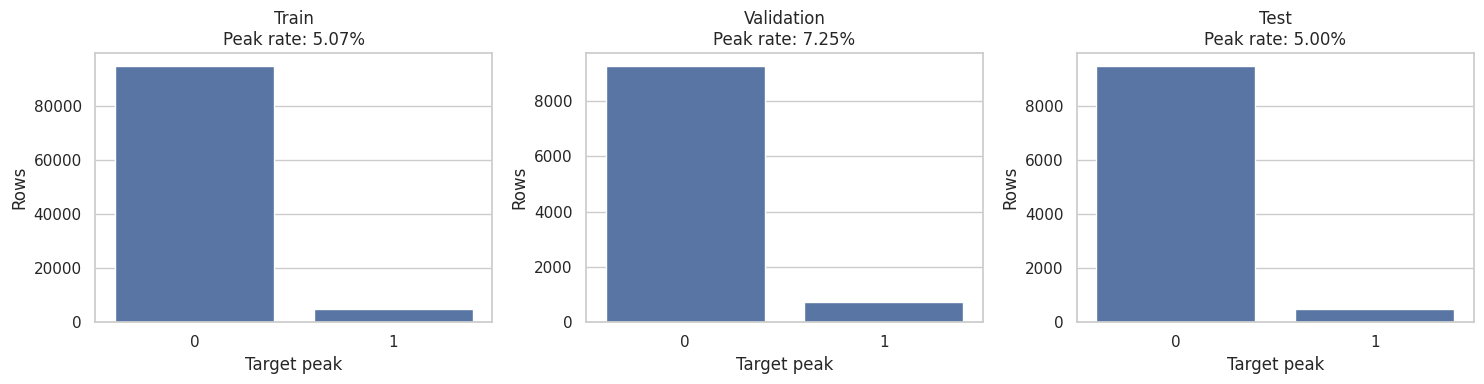

,missing_rate
load_lag_0h_w,0.0
load_lag_1h_w,0.0
load_lag_2h_w,0.0
load_lag_3h_w,0.0
load_lag_6h_w,0.0
load_lag_12h_w,0.0
load_lag_24h_w,0.0
load_lag_48h_w,0.0
load_roll_24h_mean_w,0.0
load_roll_24h_std_w,0.0


In [12]:
def run_basic_eda(frame: pd.DataFrame) -> None:
    sns.set_theme(style="whitegrid")

    split_order = ["train", "validation", "test"]

    summary = (
        frame.groupby("split")["target_peak"]
        .agg(rows="size", peaks="sum", peak_rate="mean")
        .reindex(split_order)
    )
    display(summary)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for axis, split_name in zip(axes, split_order):
        subset = frame[frame["split"] == split_name]
        sns.countplot(data=subset, x="target_peak", ax=axis)
        axis.set_title(
            f"{split_name.title()}\n"
            f"Peak rate: {subset['target_peak'].mean():.2%}"
        )
        axis.set_xlabel("Target peak")
        axis.set_ylabel("Rows")

    plt.tight_layout()
    plt.show()

    missing = (
        frame[FEATURES + GROUPS]
        .isna()
        .mean()
        .sort_values(ascending=False)
        .rename("missing_rate")
        .to_frame()
    )
    display(missing.head(20))


if data is not None:
    run_basic_eda(data)
else:
    print("Skip: prepared modelling data is unavailable.")

## Cell 11 — Train Seasonal, XGBoost, and LightGBM models


In [22]:
def best_f1_threshold(
    y_true: np.ndarray,
    y_score: np.ndarray,
) -> float:
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    valid = np.isfinite(y_score)
    y_true, y_score = y_true[valid], y_score[valid]
    if y_true.size == 0 or y_true.sum() == 0:
        return 0.5
    if not np.isin(y_true, [0, 1]).all():
        raise ValueError("y_true must contain only 0 and 1.")
    order = np.argsort(-y_score, kind="mergesort")
    sorted_y = y_true[order]
    sorted_scores = y_score[order]

    tp = np.cumsum(sorted_y)
    fp = np.cumsum(1 - sorted_y)
    fn = sorted_y.sum() - tp

    denominator = 2 * tp + fp + fn
    f1 = np.divide(
        2 * tp,
        denominator,
        out=np.zeros_like(tp, dtype=float),
        where=denominator != 0,
    )

    final_in_tie = np.r_[
        sorted_scores[:-1] != sorted_scores[1:],
        True,
    ]
    candidate_indices = np.flatnonzero(final_in_tie)
    best_index = candidate_indices[np.argmax(f1[candidate_indices])]

    return float(sorted_scores[best_index])


def train_models(
    train_df: pd.DataFrame,
    validation_df: pd.DataFrame,
) -> Tuple[Dict, Dict]:
    x_train = train_df[FEATURES]
    y_train = train_df["target_peak"].to_numpy()

    x_validation = validation_df[FEATURES]
    y_validation = validation_df["target_peak"].to_numpy()

    positive_count = int((y_train == 1).sum())
    negative_count = int((y_train == 0).sum())

    if positive_count == 0:
        raise ValueError("The training set contains no positive peak examples.")

    imbalance_ratio = negative_count / positive_count
    estimator_count = 250 if DEMO_MODE else 600

    models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=500 if not DEMO_MODE else 200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        bootstrap=True,
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
    ),

    "XGBoost": XGBClassifier(
        n_estimators=estimator_count,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        scale_pos_weight=imbalance_ratio,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        n_jobs=-1,
        random_state=SEED,
    ),

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=estimator_count,
        num_leaves=31,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=30,
        scale_pos_weight=imbalance_ratio,
        objective="binary",
        n_jobs=-1,
        random_state=SEED,
        verbosity=-1,
    )
    
    }
    validation_scores = {
        "Seasonal 24h": (
            validation_df["load_lag_24h_w"].to_numpy() >= 1
        ).astype(float)
    }


    for model_name, model in models.items():
        print(f"Training {model_name}...")
        model.fit(x_train, y_train)
        validation_scores[model_name] = model.predict_proba(
            x_validation
        )[:, 1]

    return models, validation_scores


if train is not None and validation is not None and not train.empty and not validation.empty:
    models, validation_scores = train_models(train, validation)
    print("Training complete.")
else:
    models = validation_scores = None
    print("Skip: prepared modelling data is unavailable.")

Training Random Forest...
Training XGBoost...
Training LightGBM...
Training complete.



Top 20 Features - Random Forest


,Feature,Importance
0,load_lag_0h_w,0.099373
1,load_lag_24h_w,0.085024
2,target_hour_cos,0.083524
3,target_hour_sin,0.081815
4,load_lag_48h_w,0.075698
5,load_lag_1h_w,0.068128
6,load_lag_6h_w,0.060663
7,load_roll_168h_std_w,0.057785
8,load_lag_2h_w,0.057586
9,load_roll_24h_std_w,0.056317


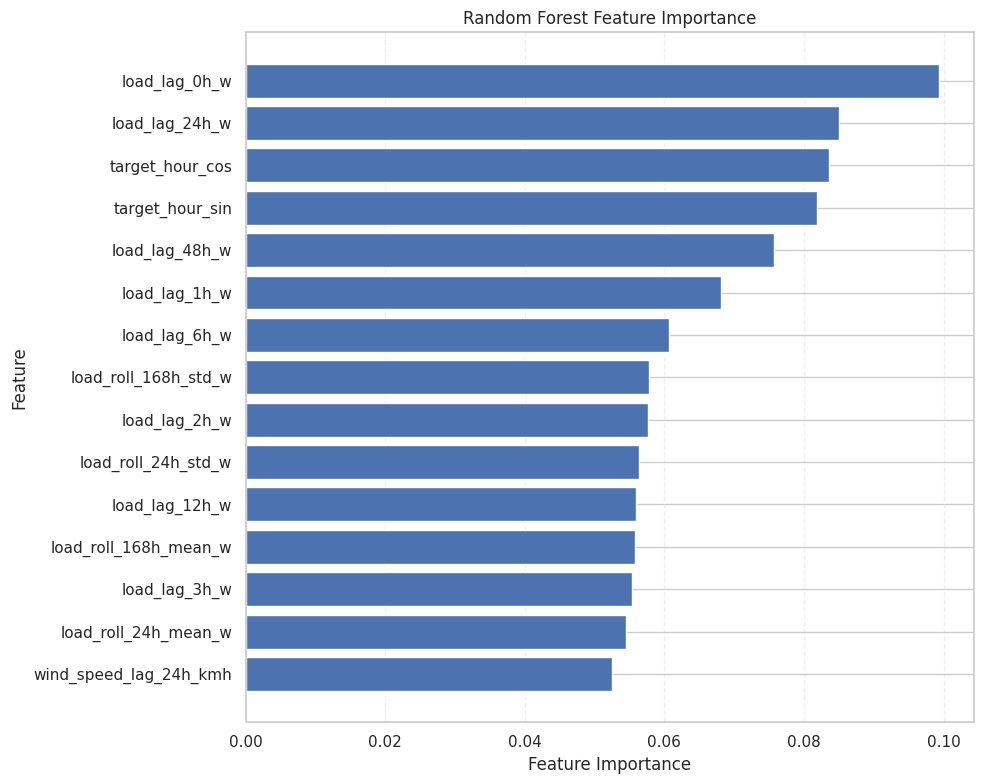


Top 20 Features - XGBoost


,Feature,Importance
0,target_hour_sin,0.270153
1,target_hour_cos,0.164320
2,load_lag_0h_w,0.091079
3,load_lag_24h_w,0.053632
4,load_lag_48h_w,0.045144
5,load_lag_6h_w,0.042408
6,load_lag_1h_w,0.041849
7,load_roll_168h_mean_w,0.038702
8,load_roll_168h_std_w,0.038562
9,load_roll_24h_std_w,0.037259


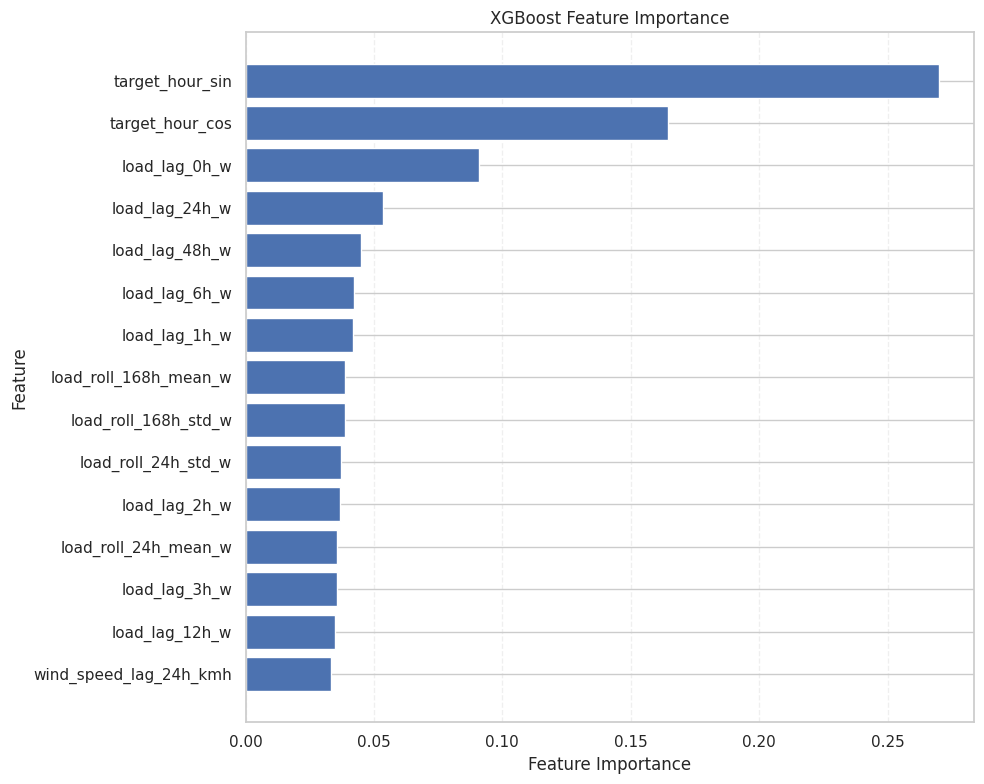


Top 20 Features - LightGBM


,Feature,Importance
0,load_roll_168h_std_w,598
1,load_lag_0h_w,583
2,load_lag_48h_w,569
3,load_lag_12h_w,554
4,wind_speed_lag_24h_kmh,549
5,load_lag_24h_w,541
6,load_roll_24h_std_w,522
7,load_roll_168h_mean_w,509
8,load_lag_3h_w,504
9,load_lag_6h_w,493


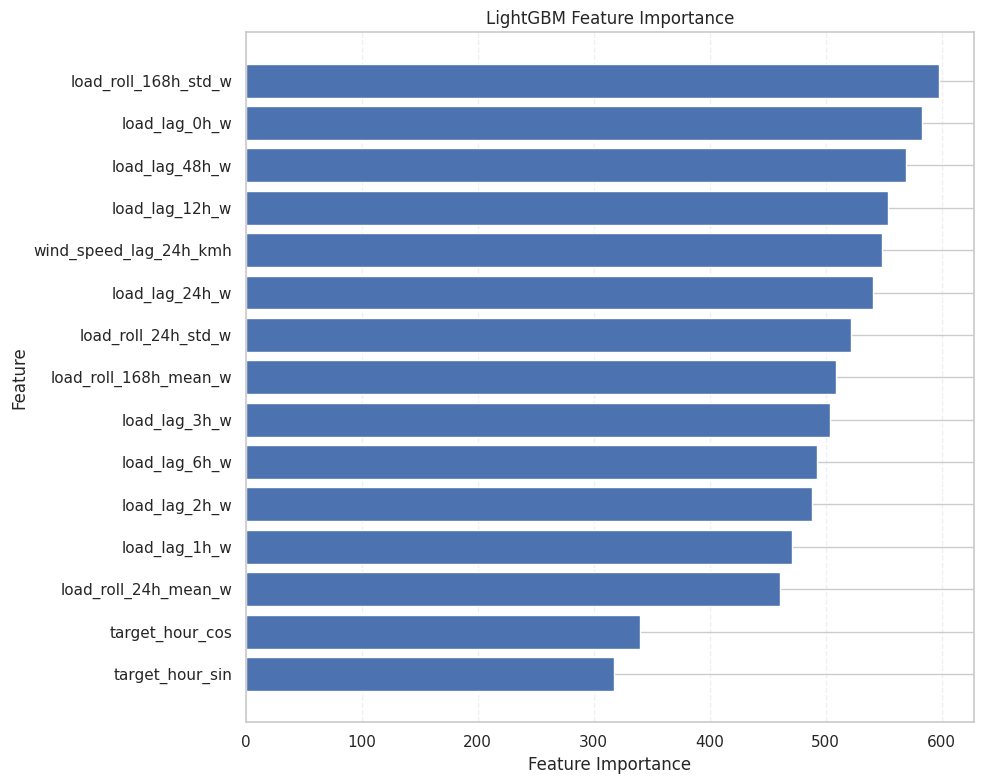

In [23]:
def plot_feature_importance(
    model,
    feature_names,
    model_name,
    top_n=20,
):
    """
    Plot feature importance for tree-based models.
    """

    if not hasattr(model, "feature_importances_"):
        print(f"{model_name} does not provide feature_importances_.")
        return None

    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    importance = (
        importance
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print(f"\nTop {top_n} Features - {model_name}")
    display(importance.head(top_n))

    plt.figure(figsize=(10, 8))

    plt.barh(
        importance["Feature"].head(top_n)[::-1],
        importance["Importance"].head(top_n)[::-1]
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title(f"{model_name} Feature Importance")

    plt.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

    return importance


# -----------------------------
# Random Forest
# -----------------------------
rf_importance = plot_feature_importance(
    models["Random Forest"],
    FEATURES,
    "Random Forest"
)

# -----------------------------
# XGBoost
# -----------------------------
xgb_importance = plot_feature_importance(
    models["XGBoost"],
    FEATURES,
    "XGBoost"
)

# -----------------------------
# LightGBM
# -----------------------------
lgb_importance = plot_feature_importance(
    models["LightGBM"],
    FEATURES,
    "LightGBM"
)

## Cell 12 — Evaluate models on the test set


In [24]:
def calculate_metrics(
    y_true: np.ndarray,
    y_score: np.ndarray,
    threshold: float,
) -> Dict:
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn) if tp + fn else 0.0
    specificity = tn / (tn + fp) if tn + fp else 0.0
    precision = tp / (tp + fp) if tp + fp else 0.0

    f1 = (
        2 * precision * sensitivity / (precision + sensitivity)
        if precision + sensitivity
        else 0.0
    )

    return {
        "roc_auc": roc_auc_score(y_true, y_score) if np.unique(y_true).size == 2 else np.nan,
        "average_precision": average_precision_score(y_true, y_score),
        "f1": f1,
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "balanced_accuracy": (sensitivity + specificity) / 2,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "threshold": threshold,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "prevalence": float(y_true.mean()),
    }


def evaluate_models(
    fitted_models: Dict,
    validation_score_map: Dict,
    validation_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, Dict, Dict]:
    y_validation = validation_df["target_peak"].to_numpy()
    y_test = test_df["target_peak"].to_numpy()

    test_scores = {
        "Seasonal 24h": (
            test_df["load_lag_24h_w"].to_numpy() >= 1
        ).astype(float)
    }

    for model_name, model in fitted_models.items():
        test_scores[model_name] = model.predict_proba(
            test_df[FEATURES]
        )[:, 1]

    rows = []
    predictions = {}

    for model_name, validation_score in validation_score_map.items():
        threshold = best_f1_threshold(
            y_validation,
            validation_score,
        )

        metrics = calculate_metrics(
            y_test,
            test_scores[model_name],
            threshold,
        )

        rows.append({"model": model_name, **metrics})
        predictions[model_name] = (
            test_scores[model_name] >= threshold
        ).astype("int8")

    return pd.DataFrame(rows), predictions, test_scores


if models is not None and test is not None and not test.empty:
    metrics_df, predictions, test_scores = evaluate_models(
        models,
        validation_scores,
        validation,
        test,
    )

    display(
        metrics_df[
            [
                "model",
                "roc_auc",
                "average_precision",
                "f1",
                "precision",
                "sensitivity",
                "specificity",
                "balanced_accuracy",
                "threshold",
            ]
        ].round(4)
    )
else:
    metrics_df = predictions = test_scores = None
    print("Skip: models were not trained.")

,model,roc_auc,average_precision,f1,precision,sensitivity,specificity,balanced_accuracy,threshold
0,Seasonal 24h,0.5563,0.0670,0.1576,0.1592,0.156,0.9566,0.5563,1.0000
1,Random Forest,0.7503,0.1520,0.2091,0.1429,0.390,0.8768,0.6334,0.2664
2,XGBoost,0.7561,0.1678,0.2149,0.1532,0.360,0.8953,0.6276,0.6464
3,LightGBM,0.7599,0.1757,0.2276,0.1673,0.356,0.9067,0.6314,0.6712


## Cell 13 — Performance plots


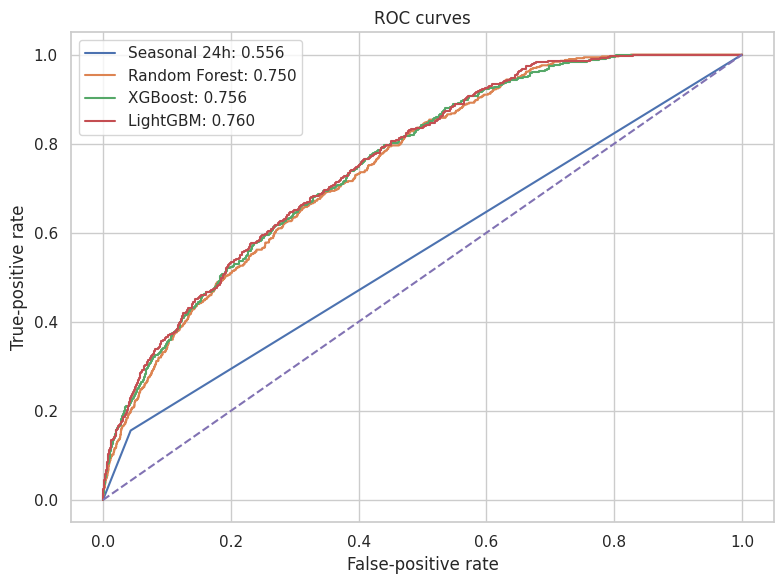

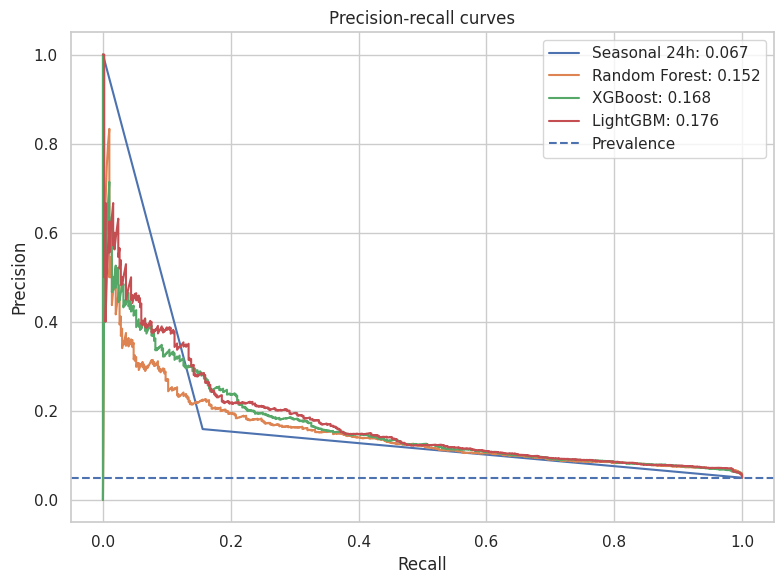

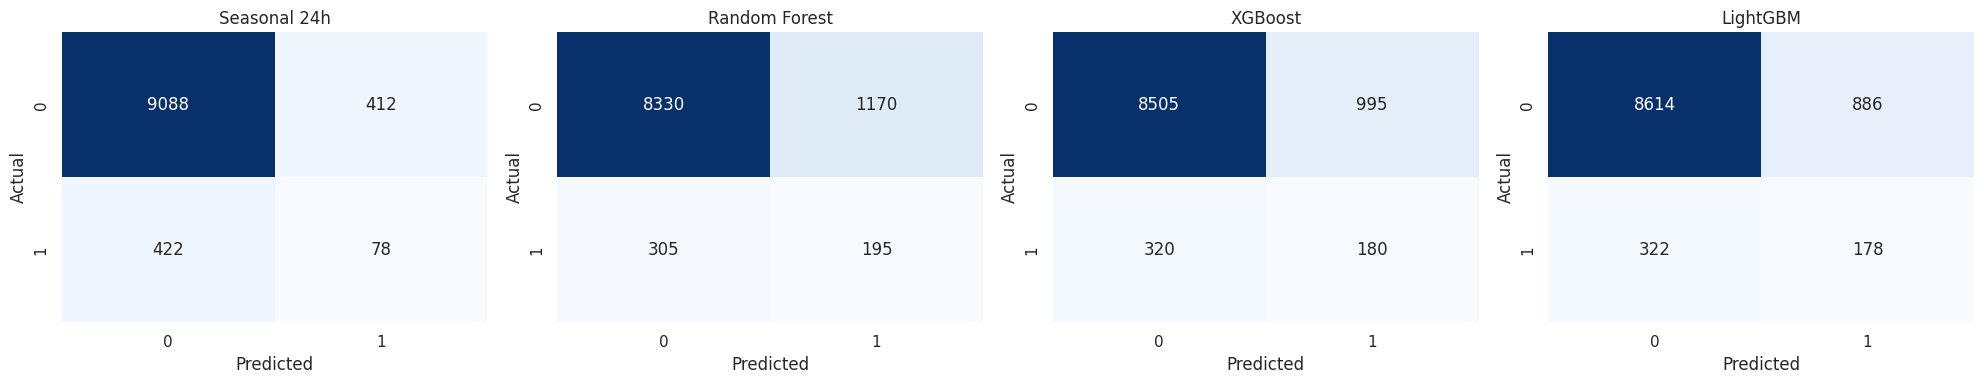

In [25]:
def plot_model_performance(
    test_df: pd.DataFrame,
    score_map: Dict,
    prediction_map: Dict,
) -> None:
    y_true = test_df["target_peak"].to_numpy()

    plt.figure(figsize=(8, 6))
    for model_name, scores in score_map.items():
        fpr, tpr, _ = roc_curve(y_true, scores)
        auc_value = roc_auc_score(y_true, scores)
        plt.plot(fpr, tpr, label=f"{model_name}: {auc_value:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False-positive rate")
    plt.ylabel("True-positive rate")
    plt.title("ROC curves")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    for model_name, scores in score_map.items():
        precision, recall, _ = precision_recall_curve(
            y_true,
            scores,
        )
        ap = average_precision_score(y_true, scores)
        plt.plot(recall, precision, label=f"{model_name}: {ap:.3f}")

    plt.axhline(y_true.mean(), linestyle="--", label="Prevalence")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-recall curves")
    plt.legend()
    plt.tight_layout()
    plt.show()

    model_count = len(prediction_map)
    fig, axes = plt.subplots(
        1,
        model_count,
        figsize=(5 * model_count, 4),
    )

    if model_count == 1:
        axes = [axes]

    for axis, (model_name, prediction) in zip(
        axes,
        prediction_map.items(),
    ):
        matrix = confusion_matrix(y_true, prediction)
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=axis,
        )
        axis.set_title(model_name)
        axis.set_xlabel("Predicted")
        axis.set_ylabel("Actual")

    plt.tight_layout()
    plt.show()


if test_scores is not None:
    plot_model_performance(test, test_scores, predictions)
else:
    print("Skip: evaluation scores are unavailable.")

## Cell 14 — Demographic fairness audit


,model,attribute,group,rows,peaks,sensitivity
0,Seasonal 24h,equivalised_income,above_median,6212,345,0.168116
1,Seasonal 24h,equivalised_income,below_median,3326,141,0.127660
2,Seasonal 24h,equivalised_income,missing,462,14,0.142857
3,Seasonal 24h,hometype,flat,6087,298,0.120805
4,Seasonal 24h,hometype,house_or_bungalow,3913,202,0.207921
5,Seasonal 24h,household_size,1,1998,118,0.169492
6,Seasonal 24h,household_size,2,4338,201,0.154229
7,Seasonal 24h,household_size,3+,3623,180,0.150000
8,Seasonal 24h,household_size,missing,41,1,0.000000
9,Random Forest,equivalised_income,above_median,6212,345,0.426087


,model,households,repeats,sensitivity_gap,ci_2.5%,ci_97.5%
0,Seasonal 24h,108,500,0.0405,0.0027,0.0986
1,Random Forest,108,500,0.1282,0.0165,0.2543
2,XGBoost,108,500,0.1089,0.0210,0.2165
3,LightGBM,108,500,0.1289,0.0426,0.2307


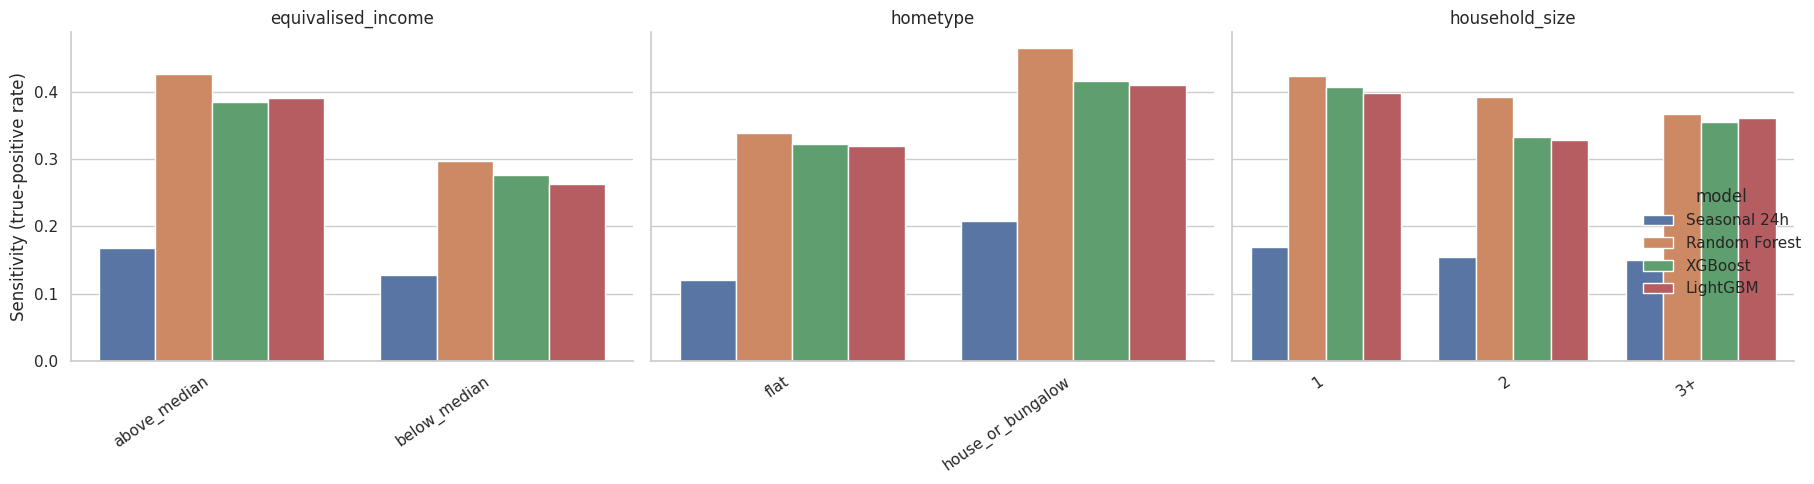

In [26]:
def group_sensitivity(
    test_df: pd.DataFrame,
    prediction_map: Dict,
) -> pd.DataFrame:
    rows = []

    for model_name, model_predictions in prediction_map.items():
        working = test_df[
            ["target_peak"] + GROUPS
        ].copy()
        working["prediction"] = model_predictions

        for attribute in GROUPS:
            for group_name, subset in working.groupby(
                attribute,
                observed=True,
            ):
                positives = subset["target_peak"] == 1
                positive_count = int(positives.sum())

                sensitivity = (
                    subset.loc[positives, "prediction"].mean()
                    if positive_count
                    else np.nan
                )

                rows.append({
                    "model": model_name,
                    "attribute": attribute,
                    "group": str(group_name),
                    "rows": len(subset),
                    "peaks": positive_count,
                    "sensitivity": sensitivity,
                })

    return pd.DataFrame(rows)


def bootstrap_income_gap(
    test_df: pd.DataFrame,
    prediction_map: Dict,
    repeats: int = BOOTSTRAP_REPEATS,
) -> pd.DataFrame:
    rng = np.random.default_rng(SEED)
    rows = []

    for model_name, model_predictions in prediction_map.items():
        frame = test_df[
            ["homeid", "equivalised_income", "target_peak"]
        ].copy()
        frame["prediction"] = model_predictions
        frame["true_positive"] = (
            frame["target_peak"] * frame["prediction"]
        )

        household_totals = (
            frame.groupby(
                ["homeid", "equivalised_income"],
                observed=True,
            )
            .agg(
                peaks=("target_peak", "sum"),
                true_positives=("true_positive", "sum"),
            )
            .reset_index()
        )

        household_totals = household_totals[
            household_totals["equivalised_income"] != "missing"
        ].reset_index(drop=True)

        if household_totals["homeid"].nunique() < 10:
            print(
                f"{model_name}: too few households for a stable bootstrap."
            )
            continue

        bootstrap_gaps = []

        for _ in range(repeats):
            sampled = household_totals.iloc[
                rng.integers(
                    0,
                    len(household_totals),
                    len(household_totals),
                )
            ]

            totals = sampled.groupby(
                "equivalised_income",
                observed=True,
            )[["peaks", "true_positives"]].sum()

            sensitivity = (
                totals["true_positives"]
                .div(totals["peaks"].replace(0, np.nan))
                .dropna()
            )

            if len(sensitivity) >= 2:
                bootstrap_gaps.append(
                    sensitivity.max() - sensitivity.min()
                )

        original_totals = household_totals.groupby(
            "equivalised_income",
            observed=True,
        )[["peaks", "true_positives"]].sum()

        original_sensitivity = (
            original_totals["true_positives"]
            .div(original_totals["peaks"].replace(0, np.nan))
            .dropna()
        )

        if len(original_sensitivity) >= 2 and bootstrap_gaps:
            rows.append({
                "model": model_name,
                "households": household_totals[
                    "homeid"
                ].nunique(),
                "repeats": len(bootstrap_gaps),
                "sensitivity_gap": (
                    original_sensitivity.max()
                    - original_sensitivity.min()
                ),
                "ci_2.5%": np.quantile(
                    bootstrap_gaps, 0.025
                ),
                "ci_97.5%": np.quantile(
                    bootstrap_gaps, 0.975
                ),
            })

    return pd.DataFrame(rows)


if predictions is not None:
    group_results = group_sensitivity(test, predictions)
    income_bootstrap = bootstrap_income_gap(
        test,
        predictions,
    )

    display(group_results.head(30))
    display(income_bootstrap.round(4))

    shown = group_results[
        (group_results["group"] != "missing")
        & group_results["sensitivity"].notna()
    ]

    if not shown.empty:
        chart = sns.catplot(
            data=shown,
            x="group",
            y="sensitivity",
            hue="model",
            col="attribute",
            kind="bar",
            sharex=False,
            height=5,
            aspect=1.1,
        )
        chart.set_xticklabels(rotation=35, ha="right")
        chart.set_axis_labels(
            "",
            "Sensitivity (true-positive rate)",
        )
        chart.set_titles("{col_name}")
        chart.figure.tight_layout()
        plt.show()
else:
    group_results = income_bootstrap = None
    print("Skip: model predictions are unavailable.")

## Cell 15 — Feature importance and save outputs


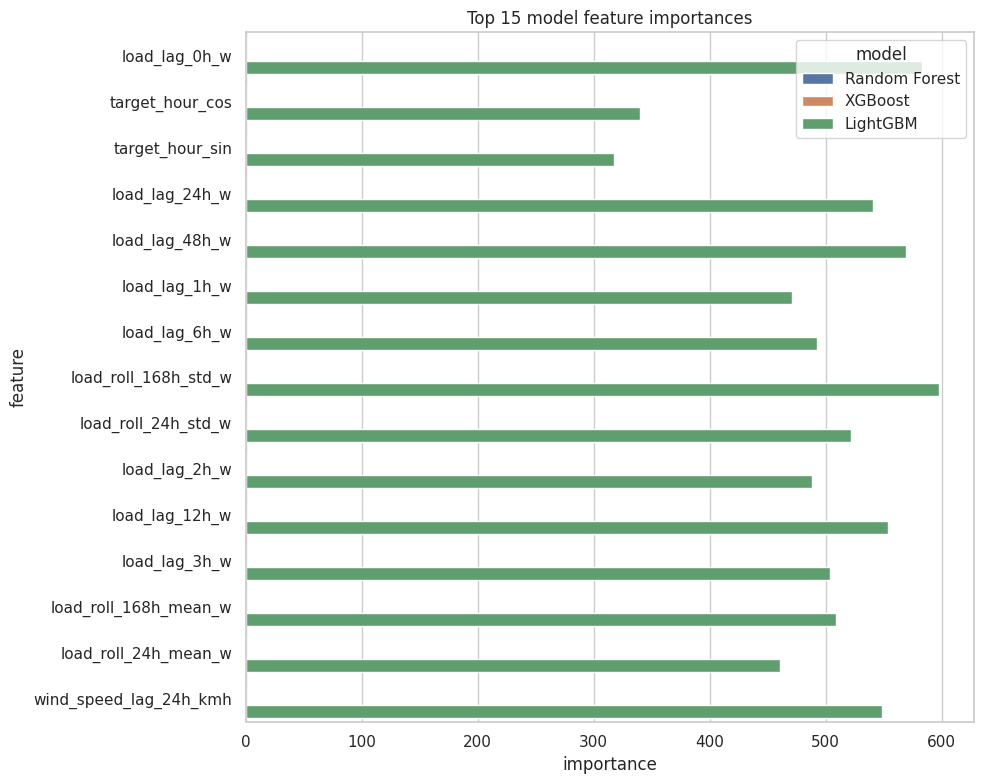

Saved output files:
 - /kaggle/working/household_peak_outputs/feature_importance.csv
 - /kaggle/working/household_peak_outputs/group_sensitivity.csv
 - /kaggle/working/household_peak_outputs/income_bootstrap.csv
 - /kaggle/working/household_peak_outputs/model_metrics.csv


In [27]:
def feature_importance_table(fitted_models: Dict) -> pd.DataFrame:
    rows = []

    for model_name, model in fitted_models.items():
        if not hasattr(model, "feature_importances_"):
            continue

        for feature_name, importance in zip(
            FEATURES,
            model.feature_importances_,
        ):
            rows.append({
                "model": model_name,
                "feature": feature_name,
                "importance": float(importance),
            })

    return pd.DataFrame(rows)


if models is not None:
    importance_df = feature_importance_table(models)

    top_features = (
        importance_df.groupby("feature")["importance"]
        .mean()
        .nlargest(15)
        .index
    )

    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=importance_df[
            importance_df["feature"].isin(top_features)
        ],
        y="feature",
        x="importance",
        hue="model",
    )
    plt.title("Top 15 model feature importances")
    plt.tight_layout()
    plt.show()

    metrics_df.to_csv(
        OUTPUT_DIR / "model_metrics.csv",
        index=False,
    )
    if group_results is not None:
        group_results.to_csv(OUTPUT_DIR / "group_sensitivity.csv", index=False)
    if income_bootstrap is not None:
        income_bootstrap.to_csv(OUTPUT_DIR / "income_bootstrap.csv", index=False)
    importance_df.to_csv(
        OUTPUT_DIR / "feature_importance.csv",
        index=False,
    )

    print("Saved output files:")
    for path in sorted(OUTPUT_DIR.glob("*")):
        print(" -", path)
else:
    print(
        "No model outputs were saved because a prepared modelling "
        "file was not found."
    )

## Dataset interpretation

`supervised_95_features.csv.gz` is already the prepared model-ready dataset. It contains 509,053 rows, chronological train/validation/test splits and complete origin weather variables. The notebook therefore does not need to merge a separate weather file before training.

The raw `sensordata.zip` is still inspected because it is the underlying household sensor source, but model training should use the prepared CSV unless you intentionally want to rebuild all features from scratch.
